# Tabulating the EoS

As an extended exercise, we expand my TOV solver to also include tabulated EoS's, to numerically solve EoS's that are provided as tabulated values of $\rho$ (rest density), $p$ (pressure), and $\epsilon$ (total density).

Sanity check is to recover known results by converting analytical EoS's into a set of tabulated EoS's, and recovering e.g. mass-radius curves from the tabulated values.

## POLYn1

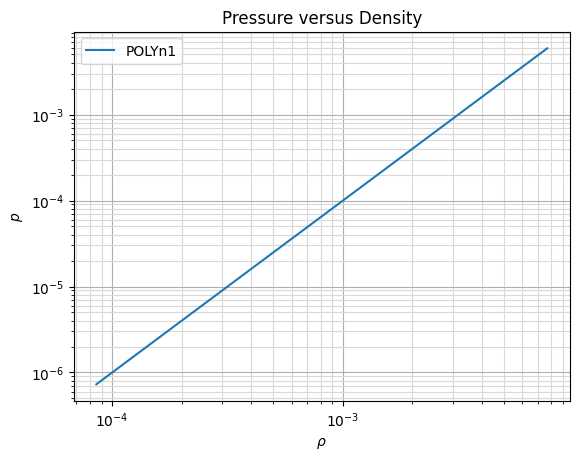

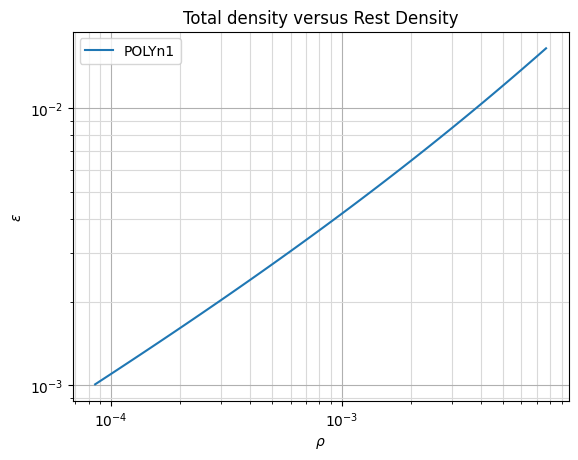

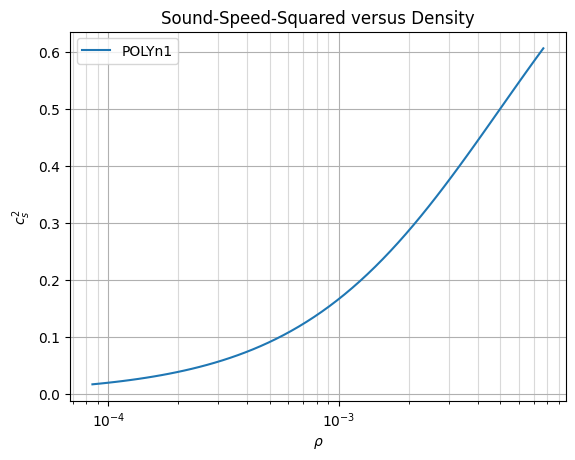

In [1]:
import pandas as pd
import numpy as np
from numpy import pi
import matplotlib.pyplot as plt
import matplotlib.cm as cmap
from astropy import units, constants as const
from scipy.integrate import ode
import pandas as pd

def eos_p(rho, K, Gamma):
    return K * rho**Gamma

def eos_eps(p, K, Gamma):
    rho_rest = (p / K)**(1/Gamma)
    return rho_rest + p/(Gamma-1)

def eos_cs2(rho, K, Gamma):
    dpdrho = Gamma * K * rho**(Gamma - 1)
    dedrho = 1 + dpdrho/(Gamma - 1)
    return dpdrho / dedrho

# Create an EOS function
def POLYn1_eos_p_and_eps():
    K = 100
    Gamma = 2
    return (
        lambda rho: eos_p(rho, K, Gamma),
        lambda p: eos_eps(p, K, Gamma),
    )

def POLYn1_eos_cs2_and_eps():
    K = 100
    Gamma = 2
    return (
        lambda rho: eos_cs2(rho, K, Gamma),
        lambda p: eos_eps(p, K, Gamma),
    )

rho_base = 1.28e-3
rho_min = 1/15 * rho_base
rho_max = 6 * rho_base
rho_c_space = np.logspace(np.log10(rho_min), np.log10(rho_max), 60)

# Plot the EOS
f1=plt.figure()
eos_p_func, _ = POLYn1_eos_p_and_eps()
plt.loglog(rho_c_space, eos_p_func(rho_c_space), label="POLYn1")
plt.title("Pressure versus Density")
plt.xlabel(r"$\rho$")
plt.ylabel(r"$p$")
plt.grid()
plt.grid(which="minor", color="0.85")
plt.legend();

f2=plt.figure()
_, eos_eps_func = POLYn1_eos_p_and_eps()
plt.loglog(rho_c_space, eos_eps_func(rho_c_space), label="POLYn1")
plt.title("Total density versus Rest Density")
plt.xlabel(r"$\rho$")
plt.ylabel(r"$\epsilon$")
plt.grid()
plt.grid(which="minor", color="0.85")
plt.legend();

f3=plt.figure()
eos_cs2_func, _ = POLYn1_eos_cs2_and_eps()
plt.semilogx(rho_c_space, eos_cs2_func(rho_c_space), label="POLYn1")
plt.title("Sound-Speed-Squared versus Density")
plt.xlabel(r"$\rho$")
plt.ylabel(r"$c_s^2$")
plt.grid()
plt.grid(which="minor", color="0.85")
plt.legend();

In [7]:
#try decreasing rho_min to, say, 1/15*base

rho_base = 1.28e-3
rho_base_new = 1.28e-10
rho_min = 1/5 * rho_base_new
rho_max = 6 * rho_base

def POLYn1_eos_data(eos_p,
                    eos_eps,
                    start_rho = rho_min,
                    stop_rho = rho_max,
                    N=5000):
    rho_vals = np.geomspace(start_rho, stop_rho, N)

    data = []

    for rho in rho_vals:
        p = eos_p(rho)
        eps = eos_eps(p)
        data.append([rho, p, eps])

    df = pd.DataFrame(data, columns=['rho', 'p', 'epsilon'])

    return df

eos_p_func, eos_eps_func = POLYn1_eos_p_and_eps()

POLYEoS_data = POLYn1_eos_data(eos_p=eos_p_func,
                                  eos_eps=eos_eps_func);



In [8]:
POLYEoS_data

,rho,p,epsilon
0,2.560000e-11,6.553600e-20,2.560000e-11
1,2.570015e-11,6.604979e-20,2.570015e-11
2,2.580070e-11,6.656761e-20,2.580070e-11
3,2.590164e-11,6.708949e-20,2.590164e-11
4,2.600297e-11,6.761546e-20,2.600297e-11
...,...,...,...
4995,7.560981e-03,5.716844e-03,1.327783e-02
4996,7.590562e-03,5.761663e-03,1.335223e-02
4997,7.620258e-03,5.806834e-03,1.342709e-02
4998,7.650071e-03,5.852358e-03,1.350243e-02


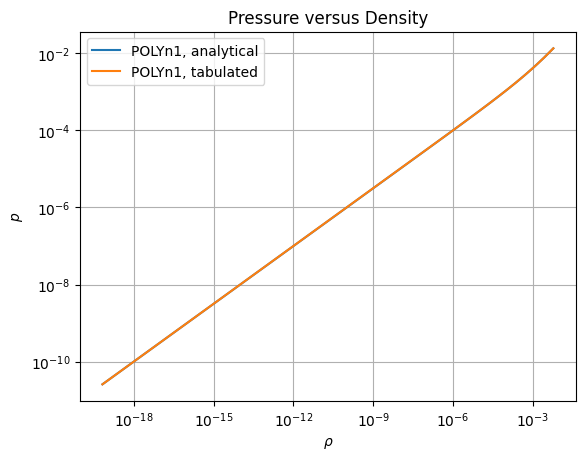

In [6]:
rho_c_nu = np.logspace(np.log10(rho_min), np.log10(rho_max))


f1=plt.figure()
eos_p_func, _ = POLYn1_eos_p_and_eps()
plt.loglog(eos_p_func(rho_c_nu), eos_eps_func(eos_p_func(rho_c_nu)), label="POLYn1, analytical")
plt.loglog(POLYEoS_data['p'], POLYEoS_data['epsilon'], label="POLYn1, tabulated")
plt.title("Pressure versus Density")
plt.xlabel(r"$\rho$")
plt.ylabel(r"$p$")
plt.grid()
plt.grid(which="minor", color="0.85")
plt.legend();

In [9]:
#Turning extrapolated data into .dat files
POLYEoS_data.to_csv(f"POLYn1_EoS_Tabulated_v2.dat",
           sep=' ',          # space-separated (standard in physics)
           index=True,       # keeps rho_central
           header=True
          )


## Piecewise EoS's

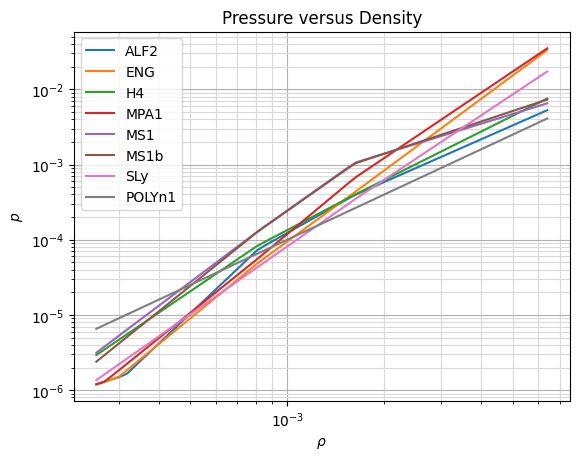

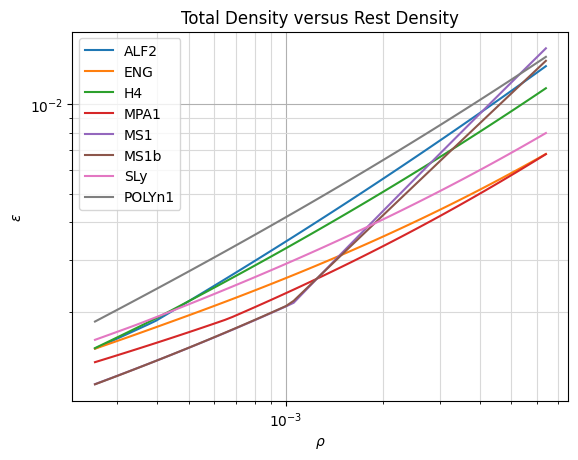

In [10]:
import pandas as pd
import numpy as np
from numpy import pi
import matplotlib.pyplot as plt
import matplotlib.cm as cmap
from astropy import units, constants as const
from scipy.integrate import ode
import pandas as pd

#Defining central EoS quantites (p, eps) out of the piecewises

# Low-density adiabatic index (common for all EoS choices)
#gamma0 = 1.3569

def eos_p_polytropic(rho, 
                     K0, K1, K2, K3, 
                     rho0, rho1, rho2, 
                     gamma0, gamma1, gamma2, gamma3):
    #global gamma0
    rho = np.asarray(rho)
    p = np.zeros_like(rho)

    mask1 = (rho>0)&(rho<=rho0)
    mask2 = (rho>rho0)&(rho<=rho1)
    mask3 = (rho>rho1)&(rho<=rho2)
    mask4 = rho>rho2

    p[mask1] = K0*rho[mask1]**gamma0
    p[mask2] = K1*rho[mask2]**gamma1
    p[mask3] = K2*rho[mask3]**gamma2
    p[mask4] = K3*rho[mask4]**gamma3

    return p

def eos_eps_polytropic(p, 
                       K0, K1, K2, K3, 
                       rho0, rho1, rho2,
                       a1, a2, a3,
                       gamma0, gamma1, gamma2, gamma3):
    #global gamma0
    
    p = np.asarray(p)
    eps = np.zeros_like(p)

    # Compute the transition pressures
    p0 = K0 * rho0**gamma0
    p1 = K1 * rho1**gamma1
    p2 = K2 * rho2**gamma2

    mask1 = (p > 0) & (p <= p0)
    mask2 = (p > p0) & (p <= p1)
    mask3 = (p > p1) & (p <= p2)
    mask4 = p > p2

    eps[mask1] = (p[mask1]/K0)**(1/gamma0) + p[mask1]/(gamma0-1)
    eps[mask2] = (1+a1)*(p[mask2]/K1)**(1/gamma1) + p[mask2]/(gamma1-1)
    eps[mask3] = (1+a2)*(p[mask3]/K2)**(1/gamma2) + p[mask3]/(gamma2-1)
    eps[mask4] = (1+a3)*(p[mask4]/K3)**(1/gamma3) + p[mask4]/(gamma3-1)

    return eps
        
polytropes = {
    'ALF2': {
        'K0': 8.9493e-02, 
        'K1': 2.8241e+08,
        'K2': 2.1056e+03, 
        'K3': 7.4029e+01,
        'rho0': 3.1534e-04,
        'rho1': 8.1147e-04,
        'rho2': 1.6191e-03,
        'a1': 1.2471e-02, 
        'a2': -2.2648e-02, 
        'a3': -1.2348e-01,
        'gamma0': 1.3569,
        'gamma1': 4.070,
        'gamma2': 2.411,
        'gamma3': 1.890,
    },
    'ENG': {
        'K0': 8.9493e-02,
        'K1': 3.5764e+06,
        'K2': 2.3260e+05, 
        'K3': 2.9693e+05,
        'rho0': 2.9919e-04,
        'rho1': 8.1147e-04,
        'rho2': 1.6191e-03,
        'a1': 1.1883e-02,
        'a2': 7.5282e-03,
        'a3': 9.7044e-03,
        'gamma0': 1.3569,
        'gamma1': 3.514,
        'gamma2': 3.130,
        'gamma3': 3.168,
    },
    'H4': {
        'K0': 8.9493e-02, 
        'K1': 8.2329e+04,
        'K2': 7.3519e+02, 
        'K3': 3.8172e+02,
        'rho0': 1.4374e-04,
        'rho1': 8.1147e-04,
        'rho2': 1.6191e-03,
        'a1': 8.6673e-03,
        'a2': -2.0209e-02,
        'a3': -3.7741e-02,
        'gamma0': 1.3569,
        'gamma1': 2.909,
        'gamma2': 2.246,
        'gamma3': 2.144,
    },
    'MPA1': {
        'K0': 8.9493e-02, 
        'K1': 2.5193e+06,
        'K2': 6.1760e+06, 
        'K3': 7.5693e+04,
        'rho0': 2.7170e-04,
        'rho1': 8.1147e-04,
        'rho2': 1.6191e-03,
        'a1': 1.1428e-02, 
        'a2':1.2818e-02,
        'a3': -4.5072e-02,
        'gamma0': 1.3569,
        'gamma1': 3.446,
        'gamma2': 3.572,
        'gamma3': 2.887,
    },
    'MS1': {
        'K0': 8.9493e-02, 
        'K1': 1.1971e+06,
        'K2': 3.0747e+05, 
        'K3': 5.2631e+00,
        'rho0': 1.5246e-04,
        'rho1': 8.1147e-04,
        'rho2': 1.6191e-03,
        'a1': 9.1399e-03,
        'a2': 2.3772e-03,
        'a3': -1.6831e+00,
        'gamma0': 1.3569,
        'gamma1': 3.224,
        'gamma2': 3.033,
        'gamma3': 1.325,
    },
    'MS1b': {
        'K0': 8.9493e-02, 
        'K1': 6.1970e+06,
        'K2': 2.6110e+05, 
        'K3': 9.7885e+00,
        'rho0': 1.8401e-04,
        'rho1': 8.1147e-04,
        'rho2': 1.6191e-03,
        'a1': 9.9510e-03,
        'a2': -4.3735e-03,
        'a3': -1.1879e+00,
        'gamma0': 1.3569,
        'gamma1': 3.456,
        'gamma2': 3.011,
        'gamma3': 1.425,
    },
    'SLy': {
        'K0': 8.9493e-02, 
        'K1': 8.4581e+04,
        'K2': 7.4943e+04, 
        'K3': 3.1074e+04,
        'rho0': 2.3674e-04,
        'rho1': 8.1147e-04,
        'rho2': 1.6191e-03,
        'a1': 1.0471e-02,
        'a2': 1.0242e-02,
        'a3': 2.3410e-03,
        'gamma0': 1.3569,
        'gamma1': 3.005,
        'gamma2': 2.988,
        'gamma3': 2.851
    },
    'POLYn1': {
        'K0': 100, 
        'K1': 100,
        'K2': 100, 
        'K3': 100,
        'rho0': 2.3674e-04,
        'rho1': 8.1147e-04,
        'rho2': 1.6191e-03,
        'a1': 0,
        'a2': 0,
        'a3': 0,
        'gamma0': 2,
        'gamma1': 2,
        'gamma2': 2,
        'gamma3': 2
    },
    # ...
}

# Create an EOS function that uses the parameters
def make_polytrope_eos_p_and_eps(name):
    params = polytropes[name]
    kaps = [params['K0'], params['K1'], params['K2'], params['K3']]
    rhos = [params['rho0'], params['rho1'], params['rho2']]
    a_s = [params['a1'], params['a2'], params['a3']]
    gammas = [params['gamma0'], params['gamma1'], params['gamma2'], params['gamma3']]
    return (
        lambda rho: eos_p_polytropic(rho, *kaps, *rhos, *gammas),
        lambda p: eos_eps_polytropic(p, *kaps, *rhos, *a_s, *gammas),
    )

# Make a list of all EOS that we want to test
eos_list_p_and_eps = [
    #("POLYn1: $K={:.0f}".format(K1) + r"$, $\Gamma=" + "{:.0f}".format(Gamma1)+ r"$", eos_p_POLYn1, eos_rho_POLYn1)]+[
    (name,) + make_polytrope_eos_p_and_eps(name) for name in polytropes ]

# Plot all EOS
 
rho_base = 1.28e-3
rho_min = 1/5 * rho_base
rho_max = 5 * rho_base
rho_c_space = np.logspace(np.log10(rho_min),np.log10(rho_max), 60)

f1=plt.figure()
for name, eos_p, _ in eos_list_p_and_eps:
    params = polytropes[name]
    plt.loglog(rho_c_space, eos_p(rho_c_space), label=name)

plt.title("Pressure versus Density")
plt.xlabel(r"$\rho$ ")
plt.ylabel(r"$p$")
plt.grid()
plt.grid(which="minor", color="0.85")
plt.legend();

f2=plt.figure()
for name, _, eos_eps in eos_list_p_and_eps:
    params = polytropes[name]
    plt.loglog(rho_c_space, eos_eps(rho_c_space), label=name)

plt.title("Total Density versus Rest Density")
plt.xlabel(r"$\rho$ ")
plt.ylabel(r"$\epsilon$")
plt.grid()
plt.grid(which="minor", color="0.85")
plt.legend();

#f2.savefig("all_eos_cs2vrho.png", bbox_inches='tight', dpi=300)

In [11]:
rho_base = 1.28e-3
rho_base_new = 1.28e-10
rho_min = 1/5 * rho_base_new
rho_max = 6 * rho_base

def all_eos_data(eos_p,
                    eos_eps,
                    start_rho = rho_min,
                    stop_rho = rho_max,
                    N=5000):
    rho_vals = np.geomspace(start_rho, stop_rho, N)

    data = []

    for rho in rho_vals:
        p = eos_p(rho)
        eps = eos_eps(p)
        data.append([rho, p, eps])

    df = pd.DataFrame(data, columns=['rho', 'p', 'epsilon'])

    return df

#eos_p_func, eos_eps_func = POLYn1_eos_p_and_eps()

AllEoS_data = dict([
    (eos_name, all_eos_data(
        eos_p, eos_eps))
    for eos_name, eos_p, eos_eps in eos_list_p_and_eps
])


In [12]:
#Turning extrapolated data into .dat files

for eos_name, df in AllEoS_data.items():
    filename = f"{eos_name}_EoS_Tabulated.dat"
#    
    df.to_csv(
        filename,
        sep=' ',          # space-separated (standard in physics)
        index=True,       # keeps rho_central
        header=True
    )


# Importing Tabulated Values

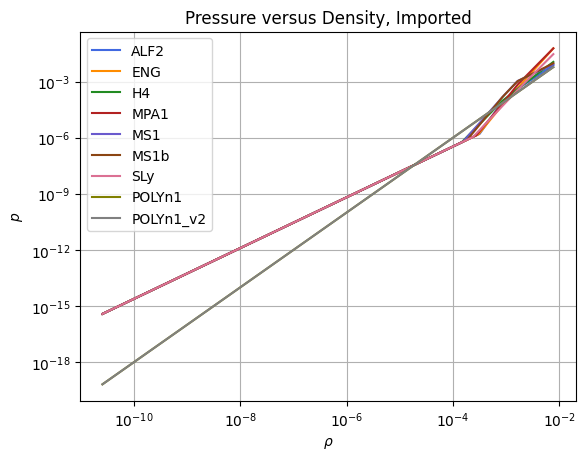

In [1]:
import pandas as pd
import numpy as np
from numpy import pi
import matplotlib.pyplot as plt
import matplotlib.cm as cmap
from astropy import units, constants as const
from scipy.integrate import ode
import pandas as pd
import itertools

#Extract MacKay Analytical Solver data to assemble MvR curve
#-------------------------------------------------------------#
ALF = np.loadtxt('ALF2_MacKay.dat')
ENG = np.loadtxt('ENG_MacKay.dat')
H4 = np.loadtxt('H4_MacKay.dat')
MPA1 = np.loadtxt('MPA1_MacKay.dat')
MS1 = np.loadtxt('MS1_MacKay.dat')
MS1B = np.loadtxt('MS1b_MacKay.dat')
SLY = np.loadtxt('SLy_MacKay.dat')
POLYn1 = np.loadtxt('POLYn1_MacKay.dat')

AfD = pd.DataFrame(ALF, columns=["rho_central", "M", "R"])
EfD = pd.DataFrame(ENG, columns=["rho_central", "M", "R"])
HfD = pd.DataFrame(H4, columns=["rho_central", "M", "R"])
MpfD = pd.DataFrame(MPA1, columns=["rho_central", "M", "R"])
MsfD = pd.DataFrame(MS1, columns=["rho_central", "M", "R"])
MsbfD = pd.DataFrame(MS1B, columns=["rho_central", "M", "R"])
SfD = pd.DataFrame(SLY, columns=["rho_central", "M", "R"])
PfD = pd.DataFrame(POLYn1, columns=["rho_central", "M", "R"])

# mass
M_ALF = AfD["M"].to_numpy()
M_ENG = EfD["M"].to_numpy()
M_H4 = HfD["M"].to_numpy()
M_MPA1 = MpfD["M"].to_numpy()
M_MS1 = MsfD["M"].to_numpy()
M_MS1B = MsbfD["M"].to_numpy()
M_SLY = SfD["M"].to_numpy()
M_POLY = PfD["M"].to_numpy()

# radius in Schw.
R_ALF = AfD["R"].to_numpy()
R_ENG = EfD["R"].to_numpy()
R_H4 = HfD["R"].to_numpy()
R_MPA1 = MpfD["R"].to_numpy()
R_MS1 = MsfD["R"].to_numpy()
R_MS1B = MsbfD["R"].to_numpy()
R_SLY = SfD["R"].to_numpy()
R_POLY = PfD["R"].to_numpy()

# rho central
r_ALF = AfD["rho_central"].to_numpy()
r_ENG = EfD["rho_central"].to_numpy()
r_H4 = HfD["rho_central"].to_numpy()
r_MPA1 = MpfD["rho_central"].to_numpy()
r_MS1 = MsfD["rho_central"].to_numpy()
r_MS1B = MsbfD["rho_central"].to_numpy()
r_SLY = SfD["rho_central"].to_numpy()
r_POLY = PfD["rho_central"].to_numpy()
#==================================================

#Extract Tabulated EoS data to solve TOVs and create MvR curves
#--------------------------------------------------------------
ALFe = np.loadtxt('ALF2_EoS_Tabulated.dat')
ENGe = np.loadtxt('ENG_EoS_Tabulated.dat')
H4e = np.loadtxt('H4_EoS_Tabulated.dat')
MPA1e = np.loadtxt('MPA1_EoS_Tabulated.dat')
MS1e = np.loadtxt('MS1_EoS_Tabulated.dat')
MS1Be = np.loadtxt('MS1b_EoS_Tabulated.dat')
SLYe = np.loadtxt('SLy_EoS_Tabulated.dat')
POLYn1e = np.loadtxt('POLYn1_EoS_Tabulated.dat')
Pe2 = np.loadtxt('POLYn1_EoS_Tabulated_v2.dat')

AfDe = pd.DataFrame(ALFe, columns=[" ","rho", "p", "epsilon"])
EfDe = pd.DataFrame(ENGe, columns=[" ","rho", "p", "epsilon"])
HfDe = pd.DataFrame(H4e, columns=[" ","rho", "p", "epsilon"])
MpfDe = pd.DataFrame(MPA1e, columns=[" ","rho", "p", "epsilon"])
MsfDe = pd.DataFrame(MS1e, columns=[" ","rho", "p", "epsilon"])
MsbfDe = pd.DataFrame(MS1Be, columns=[" ","rho", "p", "epsilon"])
SfDe = pd.DataFrame(SLYe, columns=[" ","rho", "p", "epsilon"])
PfDe = pd.DataFrame(POLYn1e, columns=[" ","rho", "p", "epsilon"])
PfDe2 = pd.DataFrame(Pe2, columns=[" ","rho", "p", "epsilon"])

# rho_rest
rho_ALF = AfDe["rho"].to_numpy()
rho_ENG = EfDe["rho"].to_numpy()
rho_H4 = HfDe["rho"].to_numpy()
rho_MPA1 = MpfDe["rho"].to_numpy()
rho_MS1 = MsfDe["rho"].to_numpy()
rho_MS1B = MsbfDe["rho"].to_numpy()
rho_SLY = SfDe["rho"].to_numpy()
rho_POLY = PfDe["rho"].to_numpy()
rho_Pv2 = PfDe2["rho"].to_numpy()

# pressure
p_ALF = AfDe["p"].to_numpy()
p_ENG = EfDe["p"].to_numpy()
p_H4 = HfDe["p"].to_numpy()
p_MPA1 = MpfDe["p"].to_numpy()
p_MS1 = MsfDe["p"].to_numpy()
p_MS1B = MsbfDe["p"].to_numpy()
p_SLY = SfDe["p"].to_numpy()
p_POLY = PfDe["p"].to_numpy()
p_Pv2 = PfDe2["p"].to_numpy()

# epsilon
e_ALF = AfDe["epsilon"].to_numpy()
e_ENG = EfDe["epsilon"].to_numpy()
e_H4 = HfDe["epsilon"].to_numpy()
e_MPA1 = MpfDe["epsilon"].to_numpy()
e_MS1 = MsfDe["epsilon"].to_numpy()
e_MS1B = MsbfDe["epsilon"].to_numpy()
e_SLY = SfDe["epsilon"].to_numpy()
e_POLY = PfDe["epsilon"].to_numpy()
e_Pv2 = PfDe2["epsilon"].to_numpy()
#===================================================

fig=plt.figure()

plt.loglog(rho_ALF, p_ALF, ls='-', color='royalblue', label='ALF2')
plt.loglog(rho_ENG, p_ENG, ls='-', color='darkorange', label='ENG')
plt.loglog(rho_H4, p_H4, ls='-', color='forestgreen', label='H4')
plt.loglog(rho_MPA1, p_MPA1, ls='-', color='firebrick', label='MPA1')
plt.loglog(rho_MS1, p_MS1, ls='-', color='slateblue', label='MS1')
plt.loglog(rho_MS1B, p_MS1B, ls='-', color='saddlebrown', label='MS1b')
plt.loglog(rho_SLY, p_SLY, ls='-', color='palevioletred', label='SLy')
plt.loglog(rho_POLY, p_POLY, ls='-', color='olive', label='POLYn1')
plt.loglog(rho_Pv2, p_Pv2, ls='-', color='gray', label='POLYn1_v2')

plt.xlabel(r"$\rho$")
plt.ylabel(r"$p$")
plt.title("Pressure versus Density, Imported")
plt.legend()
plt.grid()
plt.grid(which="minor", color="0.85");

#fig.savefig("MRCurve_data_vs_solver.png", bbox_inches='tight', dpi=300)

# Interpolation

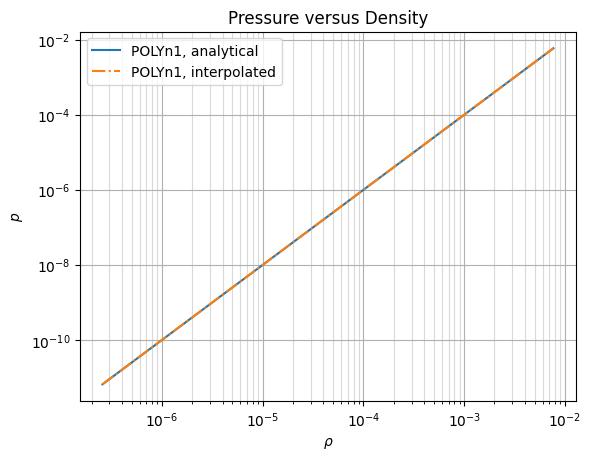

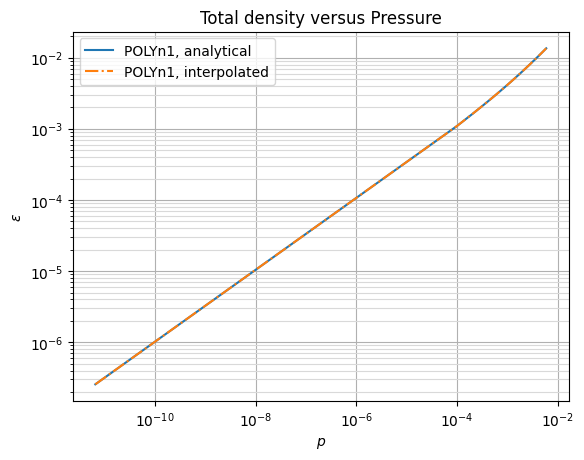

In [10]:
#Interpolation

def eos_p_POLY(rho):
    return np.interp(rho, rho_Pv2, p_Pv2)

def eos_eps_POLY(p):
    return np.interp(p, p_Pv2, e_Pv2)

#Analytical

def eos_p(rho, K, Gamma):
    return K * rho**Gamma

def eos_eps(p, K, Gamma):
    rho_rest = (p / K)**(1/Gamma)
    return rho_rest + p/(Gamma-1)

def POLYn1_eos_p_and_eps():
    K = 100
    Gamma = 2
    return (
        lambda rho: eos_p(rho, K, Gamma),
        lambda p: eos_eps(p, K, Gamma),
    )

rho_c_space = np.linspace(np.min(rho_Pv2), np.max(rho_Pv2), 60)
p_c_space = np.linspace(np.min(p_Pv2), np.max(p_Pv2), 60)

# Plot the EOS
f1=plt.figure()
eos_p_func, _ = POLYn1_eos_p_and_eps()
plt.loglog(rho_c_space, eos_p_func(rho_c_space), label="POLYn1, analytical")
plt.loglog(rho_c_space, eos_p_POLY(rho_c_space),ls='-.', label="POLYn1, interpolated")
plt.title("Pressure versus Density")
plt.xlabel(r"$\rho$")
plt.ylabel(r"$p$")
plt.grid()
plt.grid(which="minor", color="0.85")
plt.legend();

f2=plt.figure()
_, eos_eps_func = POLYn1_eos_p_and_eps()
plt.loglog(p_c_space, eos_eps_func(p_c_space), label="POLYn1, analytical")
plt.loglog(p_c_space, eos_eps_POLY(p_c_space), ls='-.',label="POLYn1, interpolated")
plt.title("Total density versus Pressure")
plt.xlabel(r"$p$")
plt.ylabel(r"$\epsilon$")
plt.grid()
plt.grid(which="minor", color="0.85")
plt.legend();


In [11]:
## The TOV Solver ##
#------------------#

# TOV equations (Schwarzschild Coord.s!!)

def dp_dr(r, p, m, eps):
    if r <= 0:
        return 0
    return -(eps + p) * (m + 4 * pi * r**3 * p) / r / (r - 2 * m) # 2*m indicates that the coordinates are Schwarzschild
def dm_dr(r, p, m, eps):
    return 4 * pi * r**2 * eps
def tov_equations(r, p_and_m, eos_epsilon):
    eps = eos_epsilon(p_and_m[0])   # change, maybe?
    return [
        dp_dr(r, *p_and_m, eps),
        dm_dr(r, *p_and_m, eps)
    ]
#==============================
# TOV integrator, from r=0 outwards, until p=0 (we yield r=R)


def solve_tov_equations(p_central, eos_epsilon, step):  # maybe comment out eos_rho
    r_initial = 0
    p_and_m_initial = [ p_central, 0. ]
    
    integrator = ode(tov_equations).set_initial_value(p_and_m_initial, r_initial)
    integrator.set_f_params(eos_epsilon) # maybe comment out eos_rho
    integrator.set_integrator('dopri5') #also try vode
    #integrator.set_integrator('vode') #also try dopri5
    
    r_path = [ r_initial ]
    p_and_m_path = [ p_and_m_initial ]
    while integrator.successful():
        p_and_m = integrator.integrate(integrator.t + step)
        
        r_path.append(integrator.t)
        p_and_m_path.append(p_and_m)
        
        p, m = p_and_m
        if p <= 0:
            break

    r_path = np.asarray(r_path)
    p_and_m_path = np.asarray(p_and_m_path)
    return r_path, p_and_m_path[:,0], p_and_m_path[:,1]
    

/tmp/ipykernel_15516/1839536877.py:15: RuntimeWarning: invalid value encountered in scalar power
  rho_rest = (p / K)**(1/Gamma)
/home/noahmackay97/.venv/lib/python3.11/site-packages/scipy/integrate/_ode.py:438: UserWarning: dopri5: step size becomes too small
  self._y, self.t = mth(self.f, self.jac or (lambda: None),
/tmp/ipykernel_15516/1839536877.py:15: RuntimeWarning: invalid value encountered in sqrt
  rho_rest = (p / K)**(1/Gamma)


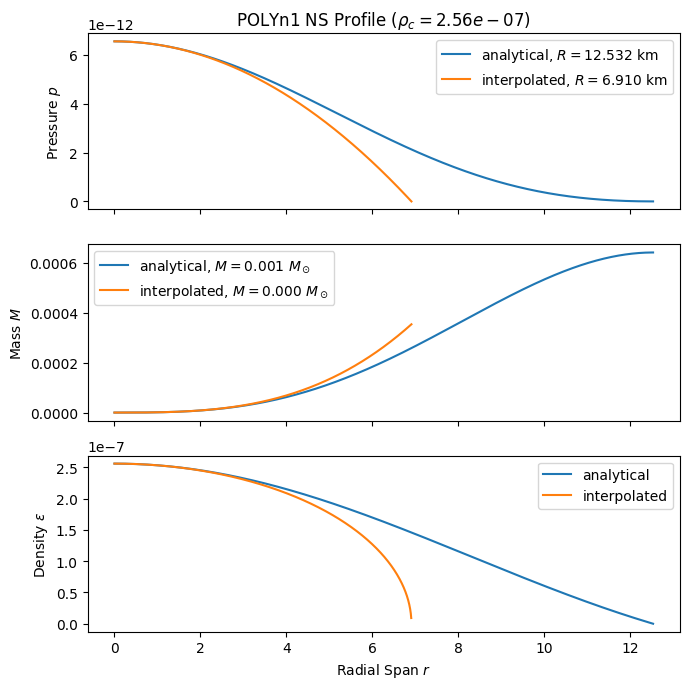

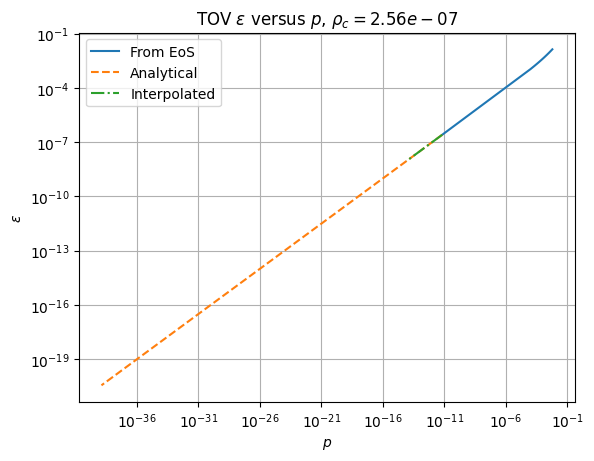

In [38]:
# Sample low-density star profile

rho_cl = np.min(rho_Pv2) #the bare minimum for the POLYn1 rho range. 
p_c_al = eos_p_func(rho_cl)
p_c_il = eos_p_POLY(rho_cl)

r1l, p1l, m1l = solve_tov_equations(                          
    p_central=p_c_al,
    eos_epsilon=eos_eps_func,
    step=0.005
)

r2l, p2l, m2l = solve_tov_equations(                          
    p_central=p_c_il,
    eos_epsilon=eos_eps_POLY,
    step=0.005
)

Ral = r1l[-1]
Mal = m1l[-1]
Ril = r2l[-1]
Mil = m2l[-1]

   #Plotting
fig, axes = plt.subplots(figsize=(7, 7), nrows=3, sharex=True)

axes[0].plot(r1l, p1l, label=r"analytical, $R = {:.3f}$".format(Ral)+" km")
axes[0].plot(r2l, p2l, label=r"interpolated, $R = {:.3f}$".format(Ril)+" km")
axes[1].plot(r1l, m1l, label=r"analytical, $M = {:.3f}$".format(Mal)+" $M_\odot$")
axes[1].plot(r2l, m2l, label=r"interpolated, $M = {:.3f}$".format(Mil)+" $M_\odot$")
axes[2].plot(r1l, eos_eps_func(p1l), label=r"analytical")
axes[2].plot(r2l, eos_eps_func(p2l), label=r"interpolated")

axes[0].set_title(r"POLYn1 NS Profile ($\rho_c = {:.2e}$".format(rho_cl)+")")
axes[0].set_ylabel(r"Pressure $p$")
axes[0].legend()

axes[1].set_ylabel(r"Mass $M$")
axes[1].legend()

axes[2].set_ylabel(r"Density $\epsilon$")
axes[2].set_xlabel(r"Radial Span $r$")
axes[2].legend()

fig.tight_layout()
plt.show()

f2=plt.figure()
_, eos_eps_func = POLYn1_eos_p_and_eps()
plt.loglog(p_c_space, eos_eps_func(p_c_space), label="From EoS")
plt.loglog(p1l, eos_eps_func(p1l),ls="--", label="Analytical")
plt.loglog(p2l, eos_eps_func(p2l), ls='-.',label="Interpolated") #"From TOV"
plt.title(r"TOV $\epsilon$ versus $p$, $\rho_c = {:.2e}$".format(rho_cl))
plt.xlabel(r"$p$")
plt.ylabel(r"$\epsilon$")
plt.grid()
plt.grid(which="minor", color="0.85")
plt.legend();

#fig.savefig("POLYn1_profs_anly_vs_interp.png", bbox_inches='tight', dpi=300)
#f2.savefig("interp_eos_v_tov_lodens.png", bbox_inches='tight', dpi=300)

There is a structural discrepancy for low density NSs, which is existent for all EoS (if we recall). Not only does the interpolated profiles end sooner than their analytical counterparts, they end at a different maximum radius.

/tmp/ipykernel_15516/1839536877.py:15: RuntimeWarning: invalid value encountered in scalar power
  rho_rest = (p / K)**(1/Gamma)
/tmp/ipykernel_15516/1839536877.py:15: RuntimeWarning: invalid value encountered in sqrt
  rho_rest = (p / K)**(1/Gamma)


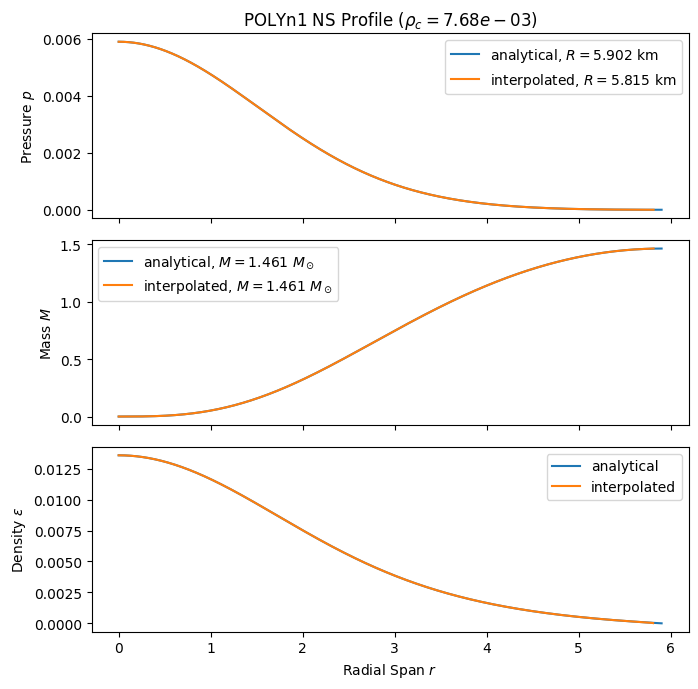

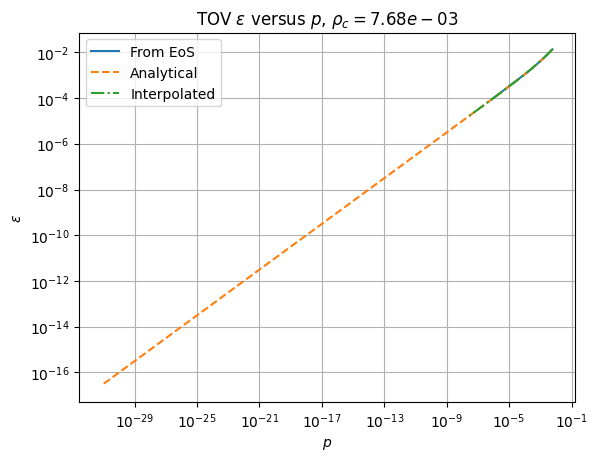

In [15]:
# Sample high-density star profile

rho_ch = np.max(rho_Pv2) #the maximum for the POLYn1 rho range. 
p_c_ah = eos_p_func(rho_ch)
p_c_ih = eos_p_POLY(rho_ch)

r1h, p1h, m1h = solve_tov_equations(                          
    p_central=p_c_ah,
    eos_epsilon=eos_eps_func,
    step=0.005
)

r2h, p2h, m2h = solve_tov_equations(                          
    p_central=p_c_ih,
    eos_epsilon=eos_eps_POLY,
    step=0.005
)

Rah = r1h[-1]
Mah = m1h[-1]
Rih = r2h[-1]
Mih = m2h[-1]

   #Plotting
fig, axes = plt.subplots(figsize=(7, 7), nrows=3, sharex=True)

axes[0].plot(r1h, p1h, label=r"analytical, $R = {:.3f}$".format(Rah)+" km")
axes[0].plot(r2h, p2h, label=r"interpolated, $R = {:.3f}$".format(Rih)+" km")
axes[1].plot(r1h, m1h, label=r"analytical, $M = {:.3f}$".format(Mah)+" $M_\odot$")
axes[1].plot(r2h, m2h, label=r"interpolated, $M = {:.3f}$".format(Mih)+" $M_\odot$")
axes[2].plot(r1h, eos_eps_func(p1h), label=r"analytical")
axes[2].plot(r2h, eos_eps_func(p2h), label=r"interpolated")

axes[0].set_title(r"POLYn1 NS Profile ($\rho_c = {:.2e}$".format(rho_ch)+")")
axes[0].set_ylabel(r"Pressure $p$")
axes[0].legend()

axes[1].set_ylabel(r"Mass $M$")
axes[1].legend()

axes[2].set_ylabel(r"Density $\epsilon$")
axes[2].set_xlabel(r"Radial Span $r$")
axes[2].legend()

fig.tight_layout()
plt.show()

f2=plt.figure()
_, eos_eps_func = POLYn1_eos_p_and_eps()
plt.loglog(p_c_space, eos_eps_func(p_c_space), label="From EoS")
plt.loglog(p1h, eos_eps_func(p1h),ls="--", label="Analytical")
plt.loglog(p2h, eos_eps_func(p2h), ls='-.',label="Interpolated") #"From TOV"
plt.title(r"TOV $\epsilon$ versus $p$, $\rho_c = {:.2e}$".format(rho_ch))
plt.xlabel(r"$p$")
plt.ylabel(r"$\epsilon$")
plt.grid()
plt.grid(which="minor", color="0.85")
plt.legend();

#fig.savefig("POLYn1_avi_hi_dens.png", bbox_inches='tight', dpi=300)
#f2.savefig("interp_eos_v_tov_hidens.png", bbox_inches='tight', dpi=300)

/tmp/ipykernel_13007/31993345.py:15: RuntimeWarning: invalid value encountered in sqrt
  rho_rest = (p / K)**(1/Gamma)


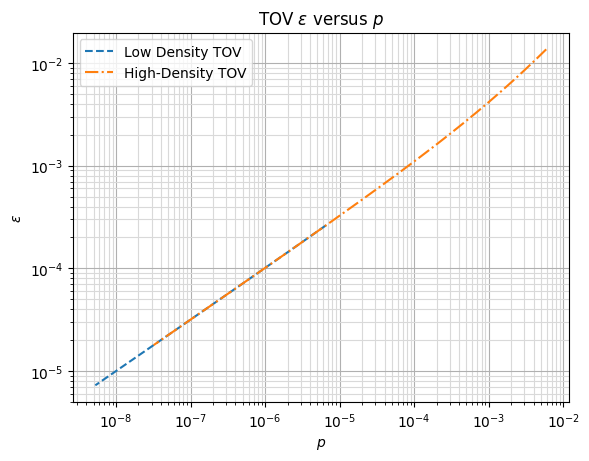

In [13]:
f2=plt.figure()
_, eos_eps_func = POLYn1_eos_p_and_eps()
#plt.loglog(p_c_space, eos_eps_func(p_c_space), label="From EoS")
plt.loglog(p2l, eos_eps_func(p2l),ls="--", label="Low Density TOV")
plt.loglog(p2h, eos_eps_func(p2h), ls='-.',label="High-Density TOV") 
plt.title(r"TOV $\epsilon$ versus $p$")
plt.xlabel(r"$p$")
plt.ylabel(r"$\epsilon$")
plt.grid()
plt.grid(which="minor", color="0.85")
plt.legend();

To be honest, I do not know what I'm looking at

I really need convincing why the interpolated approach is favorable than, say, a curve fit scheme.

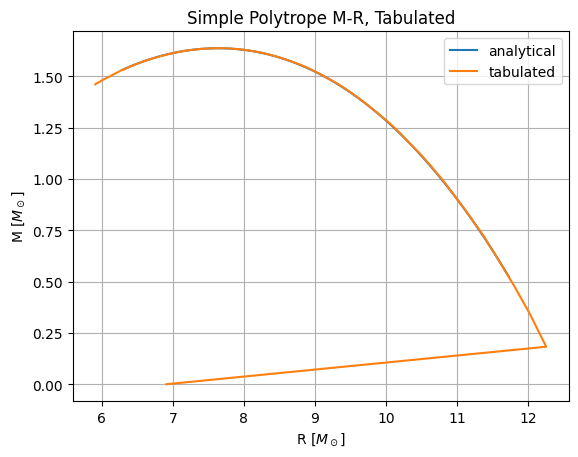

In [13]:
Pv2_MR_data = pd.DataFrame(columns=['rho_central', 'M', 'R']).set_index('rho_central')
for rho_c in np.linspace(np.min(rho_Pv2), np.max(rho_Pv2), 100):
    rho_central = rho_c
    p_c = eos_p_POLY(rho_c)
    r1, p1, m1 = solve_tov_equations(p_central=p_c,
                                         eos_epsilon=eos_eps_POLY,
                                         step=0.01)

    R = r1[-1]
    M = m1[-1]

    Pv2_MR_data.loc[rho_central] = [M, R]

f = plt.figure()
plt.plot(R_POLY, M_POLY, label="analytical")
plt.plot(Pv2_MR_data['R'], Pv2_MR_data['M'], label='tabulated')
plt.xlabel(r"R [$M_\odot$]")
plt.ylabel(r"M [$M_\odot$]")
plt.title("Simple Polytrope M-R, Tabulated")
plt.legend()
plt.grid()
plt.grid(which="minor", color="0.85");

f.savefig("dafuq.png", bbox_inches='tight', dpi=300)


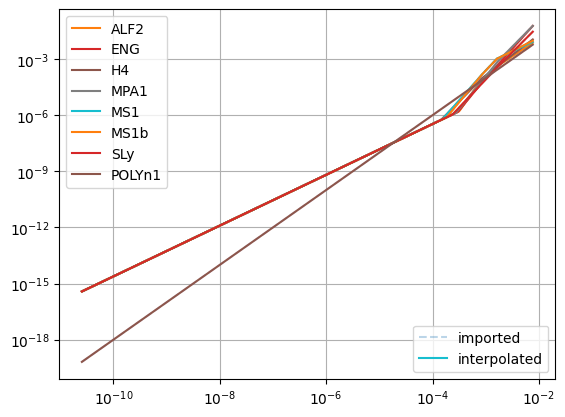

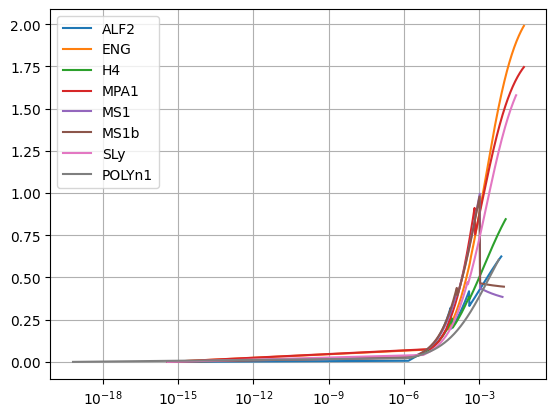

In [2]:
#make a dictionary of the imported data

pwp_data = {
    'ALF2': [rho_ALF, p_ALF, e_ALF],
    'ENG': [rho_ENG, p_ENG, e_ENG],
    'H4': [rho_H4, p_H4, e_H4],
    'MPA1': [rho_MPA1, p_MPA1, e_MPA1],
    'MS1': [rho_MS1, p_MS1, e_MS1],
    'MS1b': [rho_MS1B, p_MS1B, e_MS1B],
    'SLy': [rho_SLY, p_SLY, e_SLY],
    'POLYn1': [rho_POLY, p_POLY, e_POLY],
}

cs2_tables = {}

for name, (_, p_tab, e_tab) in pwp_data.items():
    cs2_tables[name] = np.gradient(p_tab, e_tab)

def eos_p_pwp(rho, eos_name):
    rho_tab, p_tab, _ = pwp_data[eos_name]
    return np.interp(rho, rho_tab, p_tab)

def eos_eps_pwp(p, eos_name):
    _, p_tab, e_tab = pwp_data[eos_name]
    return np.interp(p, p_tab, e_tab)

def eos_cs2_pwp(p, eos_name):
    _, p_tab, _ = pwp_data[eos_name]
    return np.interp(p, p_tab, cs2_tables[eos_name])

for name, (rho_tab, p_tab, _) in pwp_data.items():
    rho_interp = np.linspace(rho_tab.min(), rho_tab.max(), 5000)

    plt.loglog(rho_tab, p_tab, ls='--', alpha=0.3)
    plt.loglog(rho_interp, eos_p_pwp(rho_interp, name), label=name)    
#
colors = ['b', 'r', 'g', 'c']
parameters = [1,2,3,4]
for p in parameters:

  color = colors[parameters.index(p)]

lines = plt.gca().get_lines()
include = [0,9]
legend2 = plt.legend([lines[i] for i in include],['imported','interpolated'], loc=4)
plt.gca().add_artist(legend2)
#
plt.legend()
plt.grid()
plt.grid(which="minor", color="0.85");
plt.show();

for name, (_, p_tab, e_tab) in pwp_data.items():
    p_interp = np.linspace(p_tab.min(), p_tab.max(), 5000)

    #plt.loglog(rho_tab, p_tab, ls='--', alpha=0.3)
    plt.semilogx(p_interp, eos_cs2_pwp(p_interp, name), label=name)    

plt.legend()
plt.grid()
plt.grid(which="minor", color="0.85");
plt.show();

In [3]:
## The TOV Solver ##
#------------------#

# TOV equations (Schwarzschild Coord.s!!)

def dp_dr(r, p, m, eps):
    if r <= 0:
        return 0
    return -(eps + p) * (m + 4 * pi * r**3 * p) / r / (r - 2 * m) # 2*m indicates that the coordinates are Schwarzschild
    
def dm_dr(r, p, m, eps):
    return 4 * pi * r**2 * eps

def dy2_dr(r, y, p, m, eps, cs2):
    if r<=1e-6:
        return 2
    #cs2 = np.clip(cs2, 1e-12, 1.0)
    F = 1/r + (2*m/r**2 + 4*pi*r*(p-eps))/(1 - 2*m/r)
    G = (-2*(2+1)/r**2 + 4*pi*((p+eps)/(cs2) + 5*eps + 9*p) - (4*pi*r*p + m/r**2)**2/(1-2*m/r))/(1 - 2*m/r)
    return -(y**2/r + y*F + r*G)

def tov_equations(r, state, eos_eps, eos_cs2):
    p, m, y = state
    eps = eos_eps(p)
    cs2 = eos_cs2(p)
    return [
        dp_dr(r, p, m, eps),
        dm_dr(r, p, m, eps),
        dy2_dr(r, y, p, m, eps, cs2)
    ]

#==============================
# TOV integrator, from r=0 outwards, until p=0 (we yield r=R)


def solve_tov_equations(p_central, eos_eps, eos_cs2, step):  
    r_initial = 1e-10
    state_initial = [ p_central, 0., 2 ]
    
    integrator = ode(tov_equations)
    integrator.set_initial_value(state_initial, r_initial)
    integrator.set_f_params(eos_eps, eos_cs2)
    integrator.set_integrator('LSODA', rtol=1e-8, atol=1e-10, nsteps=10000, max_step=1e4) #quicker, also try dopri5
    #integrator.set_integrator('dopri5', rtol=1e-6, atol=1e-8, nsteps=10000, max_step=1e4) #slower, also try LSODA
    
    r_path = []
    p_path = []
    m_path = []
    y_path = []

    while integrator.successful():
        integrator.integrate(integrator.t + step)

        r = integrator.t
        p, m, y = integrator.y

        r_path.append(r)
        p_path.append(p)
        m_path.append(m)
        y_path.append(y)

        if p < 0:
            break
    return (np.array(r_path),
            np.array(p_path),
            np.array(m_path),
            np.array(y_path)
        )


In [4]:
all_MR_data = []

for name, (rho_tab, p_tab, e_tab) in pwp_data.items():
    rho_interp = np.linspace(rho_tab.min(), rho_tab.max(), 1000)
    for rho_c in rho_interp:
        p_c = eos_p_pwp(rho_c, name)
        r1, p1, m1, y1 = solve_tov_equations(
            p_central=p_c,
            eos_eps=lambda p: eos_eps_pwp(p, name),
            eos_cs2=lambda p: eos_cs2_pwp(p, name),
            step=0.01
        )

        R = r1[-1]
        M = m1[-1]
        Y2 = y1[-1]   

        # --- Compute compactness ---
        C = M / R

        if C < 1e-10:
            k2 = np.nan 
        else:
            log = np.log(1 - 2*C)

            k2=((8 * C**5 / 5) * (1 - 2*C)**2 * (2 + 2*C*(Y2 - 1) - Y2))/((2*C*(6 - 3*Y2 + 3*C*(5*Y2 - 8)) +
        4*C**3*(13 - 11*Y2 + C*(3*Y2 - 2) + 2*C**2*(1 + Y2)) +
        3*(1 - 2*C)**2 * (2 - Y2 + 2*C*(Y2 - 1)) * log))

        if np.isfinite(k2) and k2 > 0:
                Lambda2 = (2/3) * k2 / C**5
        else:
                Lambda2 = np.nan
        
        all_MR_data.append({
            'EOS': name,
            'rho_central': rho_c,
            'M': m1[-1],
            'R': r1[-1],
            'Lambda': Lambda2
        })

all_MR_data = pd.DataFrame(all_MR_data)

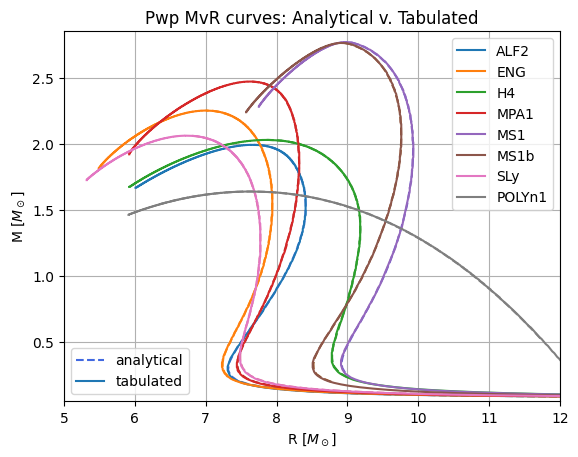

In [5]:
f = plt.figure()
plt.plot(R_ALF, M_ALF, ls='--', color='royalblue')
plt.plot(R_ENG, M_ENG, ls='--', color='darkorange')
plt.plot(R_H4, M_H4, ls='--', color='forestgreen')
plt.plot(R_MPA1, M_MPA1, ls='--', color='firebrick')
plt.plot(R_MS1, M_MS1, ls='--', color='slateblue')
plt.plot(R_MS1B, M_MS1B, ls='--', color='saddlebrown')
plt.plot(R_SLY, M_SLY, ls='--', color='palevioletred')
plt.plot(R_POLY, M_POLY, ls='--', color='grey')
#
for eos in all_MR_data['EOS'].unique():
    df = all_MR_data[all_MR_data['EOS'] == eos]

    plt.plot(df['R'], df['M'], label=eos)
#
colors = ['b', 'r', 'g', 'c']
parameters = [1,2,3,4]
for p in parameters:

  color = colors[parameters.index(p)]

lines = plt.gca().get_lines()
include = [0,8]
legend2 = plt.legend([lines[i] for i in include],['analytical','tabulated'], loc=3)
plt.gca().add_artist(legend2)
#
plt.xlabel(r"R [$M_\odot$]")
plt.xlim(5,12)
plt.ylabel(r"M [$M_\odot$]")
plt.ylim(0.05, 2.85)
plt.title("Pwp MvR curves: Analytical v. Tabulated")
plt.legend()
plt.grid()
plt.grid(which="minor", color="0.85");
plt.show()

#f.savefig("pwp_mvr_compare_v2.png", bbox_inches='tight', dpi=300)

In [6]:
# Importing BAM data

alf = np.loadtxt('alf2_mvsr.dat')
eng = np.loadtxt('eng_mvsr.dat')
h = np.loadtxt('h4_mvsr.dat')
mpa = np.loadtxt('mpa1_mvsr.dat')
ms = np.loadtxt('ms1_mvsr.dat')
msb = np.loadtxt('ms1b_mvsr.dat')
sly = np.loadtxt('sly_mvsr.dat')
polyn1 = np.loadtxt('g2k100_mvsr.dat')


afD = pd.DataFrame(alf, columns=["rho_c", "R_iso", "M", "Mb", "R", "Lambda", "e_c", "R_inv"])
efD = pd.DataFrame(eng, columns=["rho_c", "R_iso", "M", "Mb", "R", "Lambda", "e_c", "R_inv"])
hfD = pd.DataFrame(h, columns=["rho_c", "R_iso", "M", "Mb", "R", "Lambda", "e_c", "R_inv"])
mpfD = pd.DataFrame(mpa, columns=["rho_c", "R_iso", "M", "Mb", "R", "Lambda", "e_c", "R_inv"])
msfD = pd.DataFrame(ms, columns=["rho_c", "R_iso", "M", "Mb", "R", "Lambda", "e_c", "R_inv"])
msbfD = pd.DataFrame(msb, columns=["rho_c", "R_iso", "M", "Mb", "R", "Lambda", "e_c", "R_inv"])
sfD = pd.DataFrame(sly, columns=["rho_c", "R_iso", "M", "Mb", "R", "Lambda", "e_c", "R_inv"])
pfD = pd.DataFrame(polyn1, columns=["rho_c", "R_iso", "M", "Mb", "R", "Lambda", "e_c", "R_inv"])


# mass
dataM_ALF = afD["M"].to_numpy()
dataM_ENG = efD["M"].to_numpy()
dataM_H4 = hfD["M"].to_numpy()
dataM_MPA1 = mpfD["M"].to_numpy()
dataM_MS1 = msfD["M"].to_numpy()
dataM_MS1B = msbfD["M"].to_numpy()
dataM_SLY = sfD["M"].to_numpy()
dataM_POLYn1 = pfD["M"].to_numpy()

# radius in Schw.
dataR_ALF = afD["R"].to_numpy()
dataR_ENG = efD["R"].to_numpy()
dataR_H4 = hfD["R"].to_numpy()
dataR_MPA1 = mpfD["R"].to_numpy()
dataR_MS1 = msfD["R"].to_numpy()
dataR_MS1B = msbfD["R"].to_numpy()
dataR_SLY = sfD["R"].to_numpy()
dataR_POLYn1 = pfD["R"].to_numpy()

# Love
dataL_ALF = afD["Lambda"].to_numpy()
dataL_ENG = efD["Lambda"].to_numpy()
dataL_H4 = hfD["Lambda"].to_numpy()
dataL_MPA1 = mpfD["Lambda"].to_numpy()
dataL_MS1 = msfD["Lambda"].to_numpy()
dataL_MS1B = msbfD["Lambda"].to_numpy()
dataL_SLY = sfD["Lambda"].to_numpy()
dataL_POLYn1 = pfD["Lambda"].to_numpy()


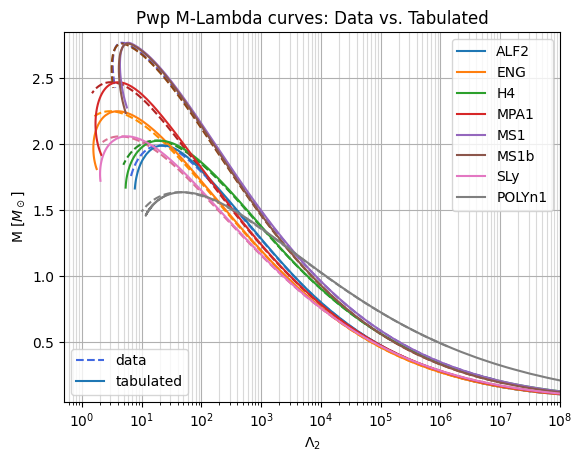

In [7]:
f=plt.figure()

plt.semilogx(dataL_ALF, dataM_ALF, ls='--', color='royalblue')
plt.semilogx(dataL_ENG, dataM_ENG, ls='--', color='darkorange')
plt.semilogx(dataL_H4, dataM_H4, ls='--', color='forestgreen')
plt.semilogx(dataL_MPA1, dataM_MPA1, ls='--', color='firebrick')
plt.semilogx(dataL_MS1, dataM_MS1, ls='--', color='slateblue')
plt.semilogx(dataL_MS1B, dataM_MS1B, ls='--', color='saddlebrown')
plt.semilogx(dataL_SLY, dataM_SLY, ls='--', color='palevioletred')
plt.semilogx(dataL_POLYn1, dataM_POLYn1, ls='--', color='grey')
#
for eos in all_MR_data['EOS'].unique():
    df = all_MR_data[all_MR_data['EOS'] == eos]

    plt.semilogx(df['Lambda'], df['M'], label=eos)
#
colors = ['b', 'r', 'g', 'c']
parameters = [1,2,3,4]
for p in parameters:

  color = colors[parameters.index(p)]

lines = plt.gca().get_lines()
include = [0,8]
legend2 = plt.legend([lines[i] for i in include],['data','tabulated'], loc=3)
plt.gca().add_artist(legend2)
#
plt.xlabel(r"$\Lambda_2$")
plt.xlim(10**(-0.3),1e8)
plt.ylabel(r"M [$M_\odot$]")
plt.ylim(0.05, 2.85)
plt.title("Pwp M-Lambda curves: Data vs. Tabulated")
plt.legend()
plt.grid()
plt.grid(which="minor", color="0.85");
plt.show()

#f.savefig("pwp_mvlam_compare_v2.png", bbox_inches='tight', dpi=300)

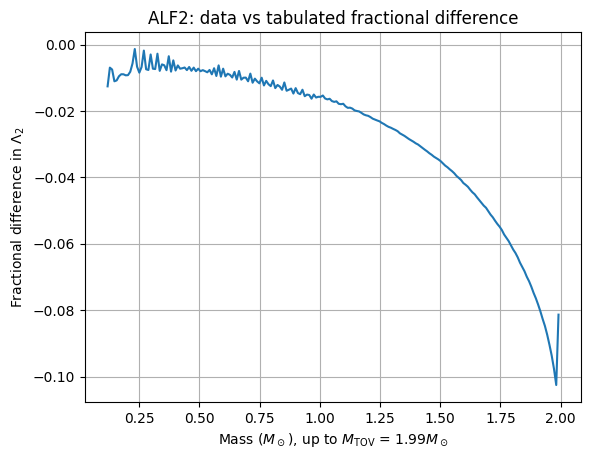

In [32]:
alf2_data = all_MR_data[all_MR_data['EOS'] == 'ALF2']
tabL_ALF = alf2_data['Lambda']
tabM_ALF = alf2_data['M']
dataL_ALF
dataM_ALF

index_mtov_tab = np.where(max(tabM_ALF)==tabM_ALF)[0][0] # only considered MR curve until mTOV
index_mtov_dat = np.where(max(dataM_ALF)==dataM_ALF)[0][0]

filtered_tab_M = tabM_ALF.to_numpy()[:index_mtov_tab+1]
filtered_tab_L = tabL_ALF.to_numpy()[:index_mtov_tab+1]

filtered_dat_M = dataM_ALF[:index_mtov_dat+1]
filtered_dat_L = dataL_ALF[:index_mtov_dat+1]

m_min = max(
    filtered_dat_M.min(),
    filtered_tab_M.min()
)

m_max = min(
    filtered_dat_M.max(),
    filtered_tab_M.max()
)

m_space = np.linspace(m_min, m_max, 200)

interp_dat_Lambda = np.interp(
    m_space,
    filtered_dat_M,
    filtered_dat_L
)

interp_tab_Lambda = np.interp(
    m_space,
    filtered_tab_M,
    filtered_tab_L
)

relative_difference_Lambda = (
    interp_dat_Lambda - interp_tab_Lambda
) / interp_tab_Lambda


frac_diff = (
    interp_dat_Lambda - interp_tab_Lambda
) / interp_tab_Lambda


f=plt.figure()
plt.plot(m_space, frac_diff)
plt.xlabel(f'Mass ($M_\\odot$), up to $M_\\mathrm{{TOV}}$ = {tabM_ALF.max():.2f}'+f'$M_\\odot$')
plt.ylabel(r'Fractional difference in $\Lambda_2$')
plt.title('ALF2: data vs tabulated fractional difference')
plt.grid()
plt.grid(which="minor", color="0.85");
plt.show()

#f.savefig("alf2_frac_diff.png", bbox_inches='tight', dpi=300)